In [ ]:
import os
import cv2
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import TensorBoard
from sklearn.metrics import classification_report
from tensorflow.keras import layers, callbacks
import warnings
warnings.filterwarnings('ignore')


In [ ]:
!unzip "RRT_Dataset.zip"

Archive:  RRT_Dataset.zip
   creating: RRT_Dataset/
   creating: RRT_Dataset/RRT Abnormal/
  inflating: RRT_Dataset/RRT Abnormal/1.jpg  
  inflating: RRT_Dataset/RRT Abnormal/10.jpg  
  inflating: RRT_Dataset/RRT Abnormal/100.jpg  
  inflating: RRT_Dataset/RRT Abnormal/101.jpg  
  inflating: RRT_Dataset/RRT Abnormal/102.jpg  
  inflating: RRT_Dataset/RRT Abnormal/103.jpg  
  inflating: RRT_Dataset/RRT Abnormal/104.jpg  
  inflating: RRT_Dataset/RRT Abnormal/105.jpg  
  inflating: RRT_Dataset/RRT Abnormal/106.jpg  
  inflating: RRT_Dataset/RRT Abnormal/107.jpg  
  inflating: RRT_Dataset/RRT Abnormal/108.jpg  
  inflating: RRT_Dataset/RRT Abnormal/109.jpg  
  inflating: RRT_Dataset/RRT Abnormal/11.jpg  
  inflating: RRT_Dataset/RRT Abnormal/110.jpg  
  inflating: RRT_Dataset/RRT Abnormal/111.jpg  
  inflating: RRT_Dataset/RRT Abnormal/112.jpg  
  inflating: RRT_Dataset/RRT Abnormal/113.jpg  
  inflating: RRT_Dataset/RRT Abnormal/114.jpg  
  inflating: RRT_Dataset/RRT Abnormal/115.jpg  
 

In [ ]:
dataset_path = 'RRT_Dataset'

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    batch_size=32,
    image_size=(224, 224),
    seed=123,
    shuffle=True,
)

# Load validation dataset without preprocessing
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    batch_size=32,
    image_size=(224, 224),
    seed=42,
)

Found 800 files belonging to 2 classes.
Using 640 files for training.
Found 800 files belonging to 2 classes.
Using 160 files for validation.


In [ ]:
class_names = sorted(os.listdir(dataset_path))

# Print the class names and the number of classes
print("Class Names:", class_names)
num_classes = len(class_names)
print("Number of Classes:", num_classes)

Class Names: ['RRT Abnormal', 'RRT Normal']
Number of Classes: 2


In [ ]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(800).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.5)
])

In [ ]:

from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model



In [ ]:
base_model = tf.keras.applications.MobileNetV3Small(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
from tensorflow.keras.layers import Input, Rescaling

# input layer
inputs = Input(shape=(224,224,3))

# apply augmentation
x = data_augmentation(inputs)

# normalize pixels
x = Rescaling(1./255)(x)

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
base_model.summary()

Model: "MobileNetV3Small"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 113, 113,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 56, 56,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 56, 56,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 56, 56,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 56, 56,    │        256 │ expanded_conv_sq

 Total params: 939,120 (3.58 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:

# Train the model with early stopping
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 269ms/step - accuracy: 0.7766 - loss: 0.4739 - val_accuracy: 0.8813 - val_loss: 0.3319
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9156 - loss: 0.2617 - val_accuracy: 0.9187 - val_loss: 0.2274
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9516 - loss: 0.1822 - val_accuracy: 0.9563 - val_loss: 0.1666
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9641 - loss: 0.1385 - val_accuracy: 0.9688 - val_loss: 0.1570
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9688 - loss: 0.1134 - val_accuracy: 0.9625 - val_loss: 0.1173
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9766 - loss: 0.0834 - val_accuracy: 0.9750 - val_loss: 0.0943
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9875 - loss: 0.0732 - val_accuracy: 0.9812 - val_loss: 0.0797
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9875 - loss: 0.0597 - val_accuracy: 0.9812 -

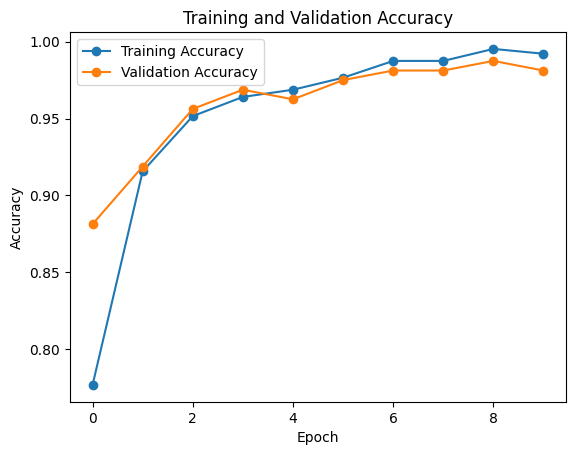

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

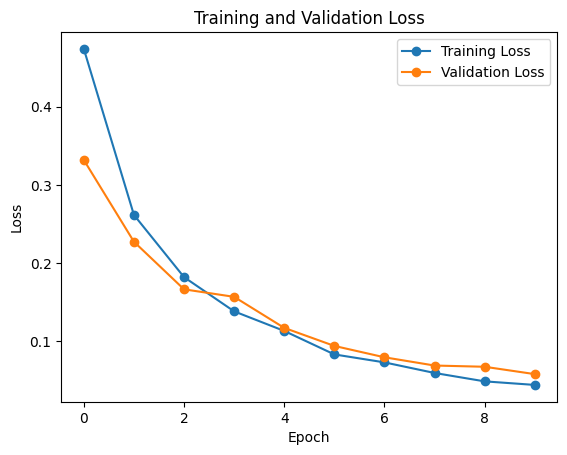

In [ ]:
plt.plot(history.history['loss'], label='Training Loss',marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss',marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
import cv2
import numpy as np

img = cv2.imread("normal_eye.jpg")
img = cv2.resize(img,(224,224))

img = img/255.0
img = np.expand_dims(img, axis=0)

pred = model.predict(img)

if pred > 0.5:
    print("RRT Normal")
else:
    print("RRT Abnormal")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
RRT Normal


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred_prob = []

for images, labels in val_ds:
    y_true.extend(labels.numpy())
    y_pred_prob.extend(model.predict(images).flatten())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary predictions

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
sensitivity = tp / (tp + fn)
print(f"Sensitivity: {sensitivity}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Sensitivity: 1.0


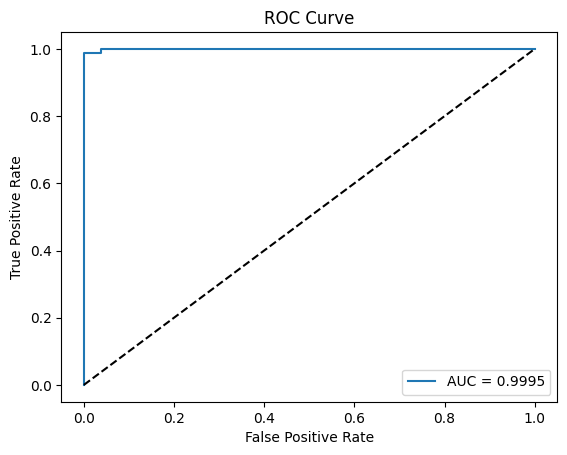

AUC Score: 0.9995


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png")
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

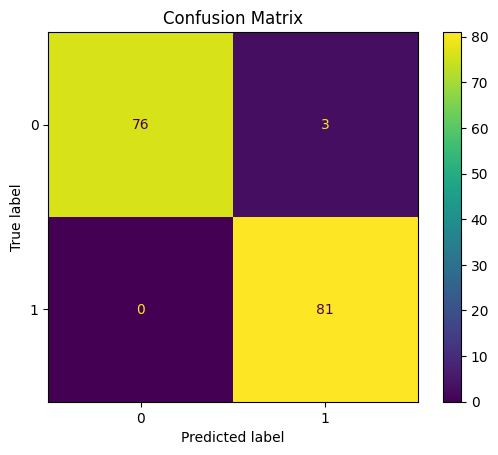

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
model.save("RRT_mobilenet_model.h5")

In [ ]:
model.save("RRT_mobilenet_model.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("RRT_mobilenet_model.h5")